In [ ]:
import os, sys, subprocess, textwrap, json, shutil, importlib
from pathlib import Path

def run(cmd, check=True, quiet=False):
    """Run a shell command, stream output."""
    print(f"\n$ {cmd}")
    r = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    out = (r.stdout or "") + (r.stderr or "")
    if not quiet:
        print(out[-6000:])
    if check and r.returncode != 0:
        raise RuntimeError(f"Command failed ({r.returncode}): {cmd}")
    return out

def section(title):
    print("\n" + "═"*78 + f"\n {title}\n" + "═"*78)

section("1. Install srt-slurm")
REPO = Path("/content/srt-slurm") if Path("/content").exists() else Path.cwd()/"srt-slurm"
if not REPO.exists():
    run(f"git clone --depth 1 https://github.com/NVIDIA/srt-slurm.git {REPO}", quiet=True)
run(f"{sys.executable} -m pip install -q -e {REPO}", quiet=True)

sys.path.insert(0, str(REPO / "src"))
importlib.invalidate_caches()

os.chdir(REPO)
run("srtctl --help")

In [ ]:
section("2. Repository architecture")
print(textwrap.dedent("""
    src/srtctl/
      cli/        submit.py (apply/dry-run/preflight/monitor), do_sweep, interactive
      core/       schema.py (typed config), sweep.py, slurm.py (sbatch gen),
                  validation.py, health.py, topology.py, fingerprint.py
      backends/   sglang.py, trtllm.py, vllm.py, mocker.py  ← engine adapters
      frontends/  Dynamo / router frontends
      templates/  Jinja2 → sbatch + orchestrator scripts
    recipes/      ready-made benchmarks per platform (gb200-fp4, h100, b200-fp8,
                  qwen3-32b, dsv4-pro, mocker smoke tests, ...)
    analysis/     srtlog (log parsers) + Streamlit dashboard (Pareto, latency...)
    docs/         sweeps.md, profiling.md, analyzing.md, config-reference.md
"""))
for d in ["recipes", "docs"]:
    print(f"{d}/ →", ", ".join(sorted(p.name for p in (REPO/d).iterdir()))[:300])

section("3. Cluster configuration (srtslurm.yaml)")
(REPO/"srtslurm.yaml").write_text(textwrap.dedent("""\
    cluster: "colab-demo"
    default_account: "demo-account"
    default_partition: "gpu"
    default_time_limit: "01:00:00"
    gpus_per_node: 4
    use_gpus_per_node_directive: true
    use_segment_sbatch_directive: true
    containers:
      dynamo-sglang: "/containers/dynamo-sglang.sqsh"
      lmsysorg+sglang+v0.5.5.post2.sqsh: "/containers/sglang-v0.5.5.sqsh"
    model_paths:
      deepseek-r1: "/models/DeepSeek-R1"
"""))
print((REPO/"srtslurm.yaml").read_text())

In [ ]:
section("4. Dry-run: mocker smoke test → generated sbatch script")
run("srtctl dry-run -f recipes/mocker/agg.yaml", check=False)

section("5. Custom disaggregated recipe (prefill/decode split)")
(REPO/"my-disagg.yaml").write_text(textwrap.dedent("""\
    name: "colab-disagg-demo"
    model:
      path: "deepseek-r1"
      container: "lmsysorg+sglang+v0.5.5.post2.sqsh"
      precision: "fp8"
    resources:
      gpu_type: "gb200"
      gpus_per_node: 4
      prefill_nodes: 1
      decode_nodes: 2
      prefill_workers: 1
      decode_workers: 2
    backend:
      prefill_environment: { PYTHONUNBUFFERED: "1" }
      decode_environment:  { PYTHONUNBUFFERED: "1" }
      sglang_config:
        prefill:
          served-model-name: "deepseek-ai/DeepSeek-R1"
          model-path: "/model/"
          trust-remote-code: true
          kv-cache-dtype: "fp8_e4m3"
          tensor-parallel-size: 4
          disaggregation-mode: "prefill"
        decode:
          served-model-name: "deepseek-ai/DeepSeek-R1"
          model-path: "/model/"
          trust-remote-code: true
          kv-cache-dtype: "fp8_e4m3"
          tensor-parallel-size: 4
          disaggregation-mode: "decode"
    benchmark:
      type: "sa-bench"
      isl: 1024
      osl: 1024
      concurrencies: [64, 128, 256]
      req_rate: "inf"
"""))
run("srtctl dry-run -f my-disagg.yaml", check=False)

In [ ]:
section("6. Parameter sweep (grid search) — dry-run + expansion on disk")
run("srtctl dry-run -f examples/example-sweep.yaml", check=False)
sweep_dirs = sorted((REPO/"dry-runs").glob("example-sweep_sweep_*"))
if sweep_dirs:
    latest = sweep_dirs[-1]
    print("Per-job configs generated by the sweep expander:")
    for p in sorted(latest.rglob("config.yaml")):
        print("  ", p.relative_to(REPO))

section("7. Programmatic use of srtctl's Python API")
import yaml
from srtctl.core.config import load_config
from srtctl.core.sweep import generate_sweep_configs, expand_template
from srtctl.core.schema import BenchmarkType, Precision, GpuType

cfg = load_config("my-disagg.yaml")
print(f"Loaded  : {cfg.name}")
print(f"Model   : {cfg.model.path} ({cfg.model.precision}) on {cfg.resources.gpu_type}")
print(f"Layout  : {cfg.resources.prefill_nodes}P + {cfg.resources.decode_nodes}D nodes, "
      f"{cfg.resources.gpus_per_node} GPUs/node")
print(f"Bench   : {cfg.benchmark.type} isl={cfg.benchmark.isl} osl={cfg.benchmark.osl} "
      f"concurrencies={cfg.benchmark.concurrencies}")
print(f"Enums   : benchmarks={[b.value for b in BenchmarkType]}")
print(f"          precisions={[p.value for p in Precision]}, gpus={[g.value for g in GpuType]}")

raw_sweep = yaml.safe_load(Path("examples/example-sweep.yaml").read_text())
jobs = generate_sweep_configs(raw_sweep)
print(f"\nSweep expands to {len(jobs)} jobs:")
for job_cfg, params in jobs:
    pf = job_cfg["backend"]["sglang_config"]["prefill"]
    print(f"  {params}  → chunked-prefill-size={pf['chunked-prefill-size']}, "
          f"max-total-tokens={pf['max-total-tokens']}")
print("\nTemplate substitution:",
      expand_template({"flag": "{x}", "n": "{y}"}, {"x": 4096, "y": 2}))

In [ ]:
section("8. Analysis: Pareto frontier from (simulated) benchmark results")
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(0)
def simulate(variant, base_tps, base_itl):
    rows = []
    for c in [16, 32, 64, 128, 256, 512]:
        tps_gpu = base_tps * c / (c + 90) * rng.uniform(.97, 1.03)
        itl     = base_itl * (1 + c/220) * rng.uniform(.97, 1.03)
        rows.append({"variant": variant, "concurrency": c,
                     "tok_s_gpu": tps_gpu, "itl_ms": itl})
    return rows

results = simulate("chunked=4096", 260, 9.5) + simulate("chunked=8192", 300, 11.5)
print(json.dumps(results[:3], indent=2), "...")

plt.figure(figsize=(8, 5))
for variant in ("chunked=4096", "chunked=8192"):
    pts = [(r["itl_ms"], r["tok_s_gpu"], r["concurrency"])
           for r in results if r["variant"] == variant]
    xs, ys, cs = zip(*pts)
    plt.plot(xs, ys, "o-", label=variant)
    for x, y, c in pts:
        plt.annotate(str(c), (x, y), fontsize=7, xytext=(3, 3),
                     textcoords="offset points")
plt.xlabel("Inter-token latency (ms/token)  →  worse")
plt.ylabel("Throughput (tokens/s/GPU)  →  better")
plt.title("Pareto frontier: sweep variants (points labeled by concurrency)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


══════════════════════════════════════════════════════════════════════════════
 1. Install srt-slurm
══════════════════════════════════════════════════════════════════════════════

$ /usr/bin/python3 -m pip install -q -e /content/srt-slurm

$ srtctl --help
usage: srtctl [-h]
              {apply,dry-run,preflight,monitor,resolve-override,diff,check}
              ...

srtctl - SLURM job submission

positional arguments:
  {apply,dry-run,preflight,monitor,resolve-override,diff,check}
    apply               Submit job(s) to SLURM
    dry-run             Validate without submitting
    preflight           Check model and container availability without
                        submitting
    monitor             Live dashboard for srt-slurm jobs
    resolve-override    Resolve override YAML into specialised files without
                        submitting
    diff                Compare fingerprints from two runs
    check               Check environment against a fingerprint

options:
  -

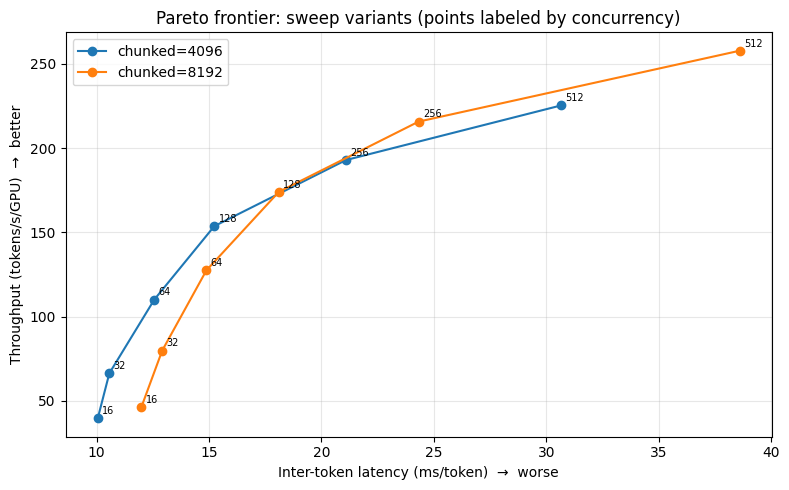


══════════════════════════════════════════════════════════════════════════════
 9. Next steps on a real cluster
══════════════════════════════════════════════════════════════════════════════
make setup ARCH=aarch64|x86_64        # one-time: NATS/ETCD + srtslurm.yaml
srtctl preflight -f my-disagg.yaml    # verify model + container paths exist
srtctl apply -f my-disagg.yaml        # submit (add --tags exp,baseline)
srtctl apply -f sweep.yaml            # sweeps auto-detected → N jobs
srtctl monitor                        # live job dashboard in terminal
uv run streamlit run analysis/dashboard/app.py   # Pareto/latency dashboards
srtctl diff runA runB                 # compare environment fingerprints
Logs land in outputs/{JOB_ID}/logs/;  analysis/srtlog parses them
(NodeAnalyzer, RunLoader) for programmatic post-processing.

Reproducibility tip (srtctl also prints this in dry-run): add an
identity: block to your recipe — HF model repo + revision, container
image URI, and framework versi

In [2]:
section("9. Next steps on a real cluster")
print(textwrap.dedent("""\
    make setup ARCH=aarch64|x86_64
    srtctl preflight -f my-disagg.yaml
    srtctl apply -f my-disagg.yaml
    srtctl apply -f sweep.yaml
    srtctl monitor
    uv run streamlit run analysis/dashboard/app.py
    srtctl diff runA runB
    Logs land in outputs/{JOB_ID}/logs/;  analysis/srtlog parses them
    (NodeAnalyzer, RunLoader) for programmatic post-processing.

    Reproducibility tip (srtctl also prints this in dry-run): add an
    identity: block to your recipe — HF model repo + revision, container
    image URI, and framework versions — so srtctl can verify the runtime
    matches your declaration at job start.
"""))
print("✅ Tutorial complete.")